In [ ]:
import ast
from pathlib import Path

import polars as pl

TIMING_RESULTS = Path("..") / "timing_results_tsp"

UNIT_TO_S = {"MILLISECONDS": 1e-3, "SECONDS": 1.0, "NANOSECONDS": 1e-9, "MINUTES": 60.0}

rows = []
for f in sorted(TIMING_RESULTS.glob("*/*/Predictions/*/testResample*.csv")):
    with open(f) as fh:
        header = fh.readline().rstrip("\n").split(",")
        params_line = fh.readline().rstrip("\n")
        result = fh.readline().rstrip("\n").split(",")
    scale = UNIT_TO_S[header[4]]
    try:
        params = ast.literal_eval(params_line)
    except (ValueError, SyntaxError):
        params = {}
    rows.append(
        {
            "run": f.parents[3].name,
            "model": f.parents[2].name,
            "dataset": f.parent.name,
            "resample": int(f.stem.removeprefix("testResample")),
            "n_gpus": params.get("n_gpus"),
            "n_jobs": params.get("n_jobs"),
            "accuracy": float(result[0]),
            "fit_s": float(result[1]) * scale,
            "predict_s": float(result[2]) * scale,
        }
    )

df = pl.DataFrame(rows, infer_schema_length=None)
print(df.group_by(["run", "model", "n_jobs", "n_gpus"]).len("n_results").sort("run", "model"))
df.head()

shape: (25, 5)
┌──────────────────────────┬─────────────────────────────────┬────────┬────────┬───────────┐
│ run                      ┆ model                           ┆ n_jobs ┆ n_gpus ┆ n_results │
│ ---                      ┆ ---                             ┆ ---    ┆ ---    ┆ ---       │
│ str                      ┆ str                             ┆ i64    ┆ i64    ┆ u32       │
╞══════════════════════════╪═════════════════════════════════╪════════╪════════╪═══════════╡
│ hc2_1cpu                 ┆ HIVECOTEV2                      ┆ 1      ┆ null   ┆ 112       │
│ mrhydra_16cpu            ┆ MultiRocketHydra                ┆ 16     ┆ null   ┆ 112       │
│ mrhydra_1cpu             ┆ MultiRocketHydra                ┆ 1      ┆ null   ┆ 112       │
│ mrhydra_4cpu             ┆ MultiRocketHydra                ┆ 4      ┆ null   ┆ 112       │
│ mrhydra_8cpu             ┆ MultiRocketHydra                ┆ 8      ┆ null   ┆ 112       │
│ …                        ┆ …                         

run,model,dataset,resample,n_gpus,n_jobs,accuracy,fit_s,predict_s
str,str,str,i64,i64,i64,f64,f64,f64
"""hc2_1cpu""","""HIVECOTEV2""","""ACSF1""",0,null,1,0.91,1253.896,933.035
"""hc2_1cpu""","""HIVECOTEV2""","""Adiac""",0,null,1,0.808184,803.425,412.292
"""hc2_1cpu""","""HIVECOTEV2""","""ArrowHead""",0,null,1,0.851429,91.778,233.143
"""hc2_1cpu""","""HIVECOTEV2""","""BME""",0,null,1,1.0,55.268,131.374
"""hc2_1cpu""","""HIVECOTEV2""","""Beef""",0,null,1,0.866667,189.497,136.259


In [ ]:
df = df.with_columns(
    (
        pl.col("model")
        + "  [n_jobs="
        + pl.col("n_jobs").cast(pl.String).fill_null("-")
        + ", n_gpus="
        + pl.col("n_gpus").cast(pl.String).fill_null("-")
        + "]"
    ).alias("config")
)
df["config"].value_counts().sort('count')

config,count
str,u32
"""TSCGlueEnhancedV4-Best-LogLoss…",111
"""TSCGlueEnhancedV4-High-LogLoss…",112
"""TSCGlueEnhancedV4-Low-LogLoss-…",112
"""TSCGlueEnhancedV4-Best-LogLoss…",112
"""MultiRocketHydra [n_jobs=1, n…",112
…,…
"""TSCGlueEnhancedV4-Medium-LogLo…",112
"""HIVECOTEV2 [n_jobs=1, n_gpus=…",112
"""TSCGlueEnhancedV4-Best-LogLoss…",112


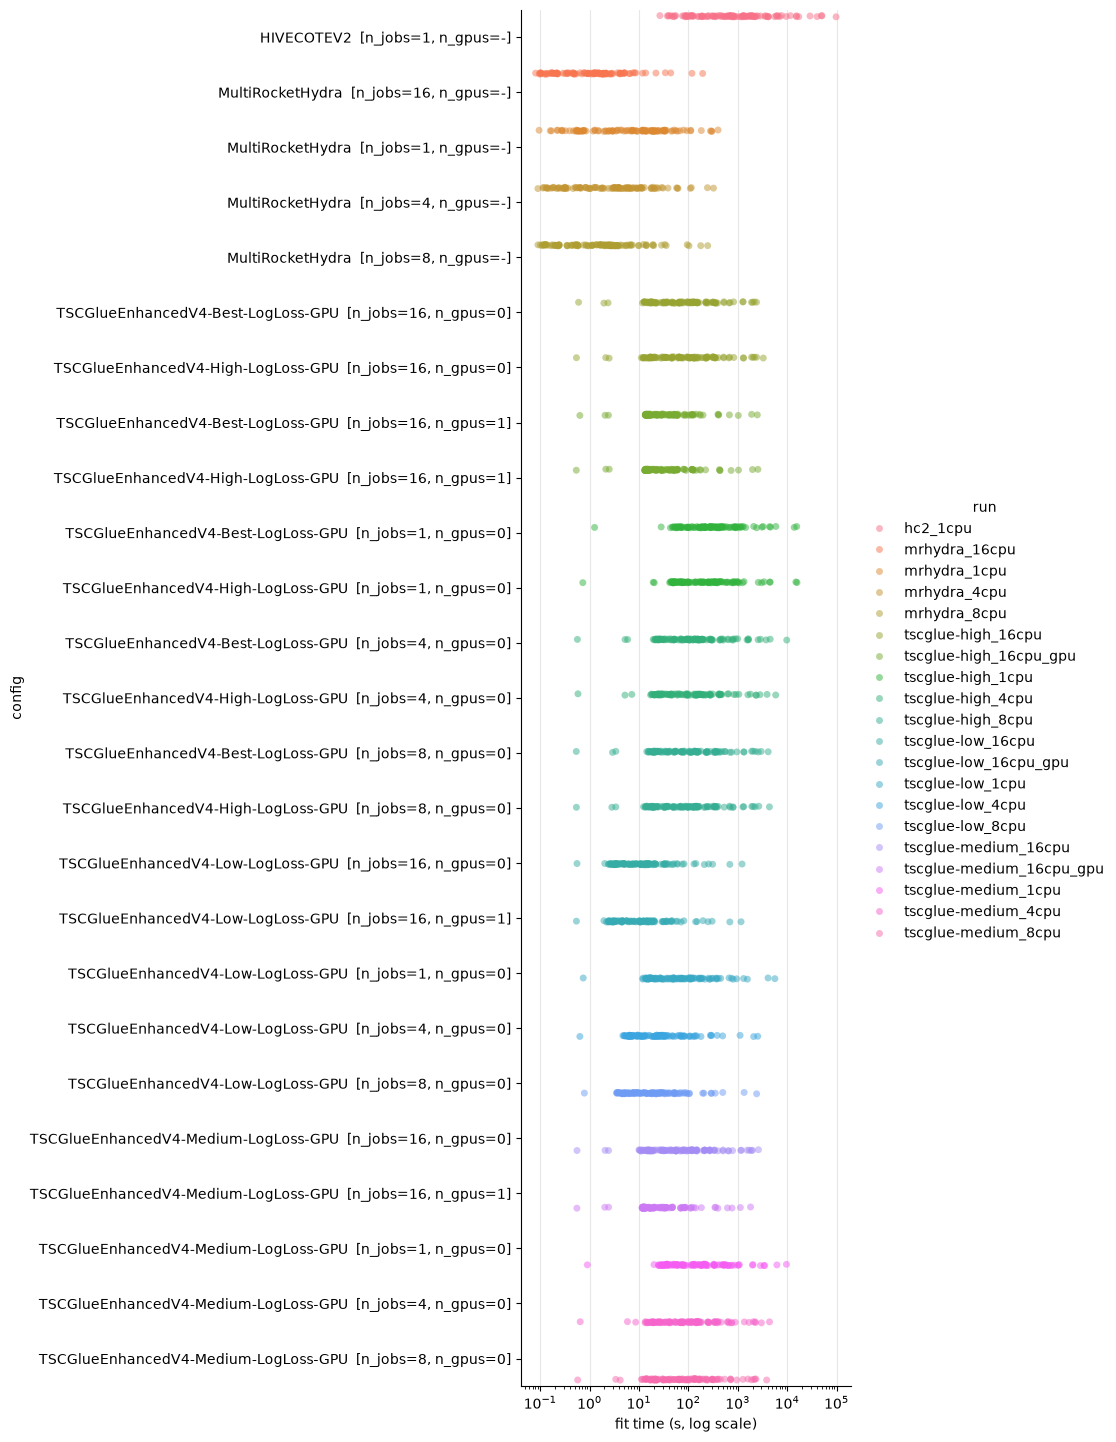

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=df,
    x="fit_s",
    y="config",
    hue="run",
    kind="strip",
    height=2 + 0.5 * df["config"].n_unique(),
    aspect=10 / (2 + 0.5 * df["config"].n_unique()),
    alpha=0.5,
    jitter=0.25,
    dodge=True,
)
g.ax.set_xscale("log")
g.ax.set_xlabel("fit time (s, log scale)")
g.ax.grid(axis="x", alpha=0.3)
plt.show()


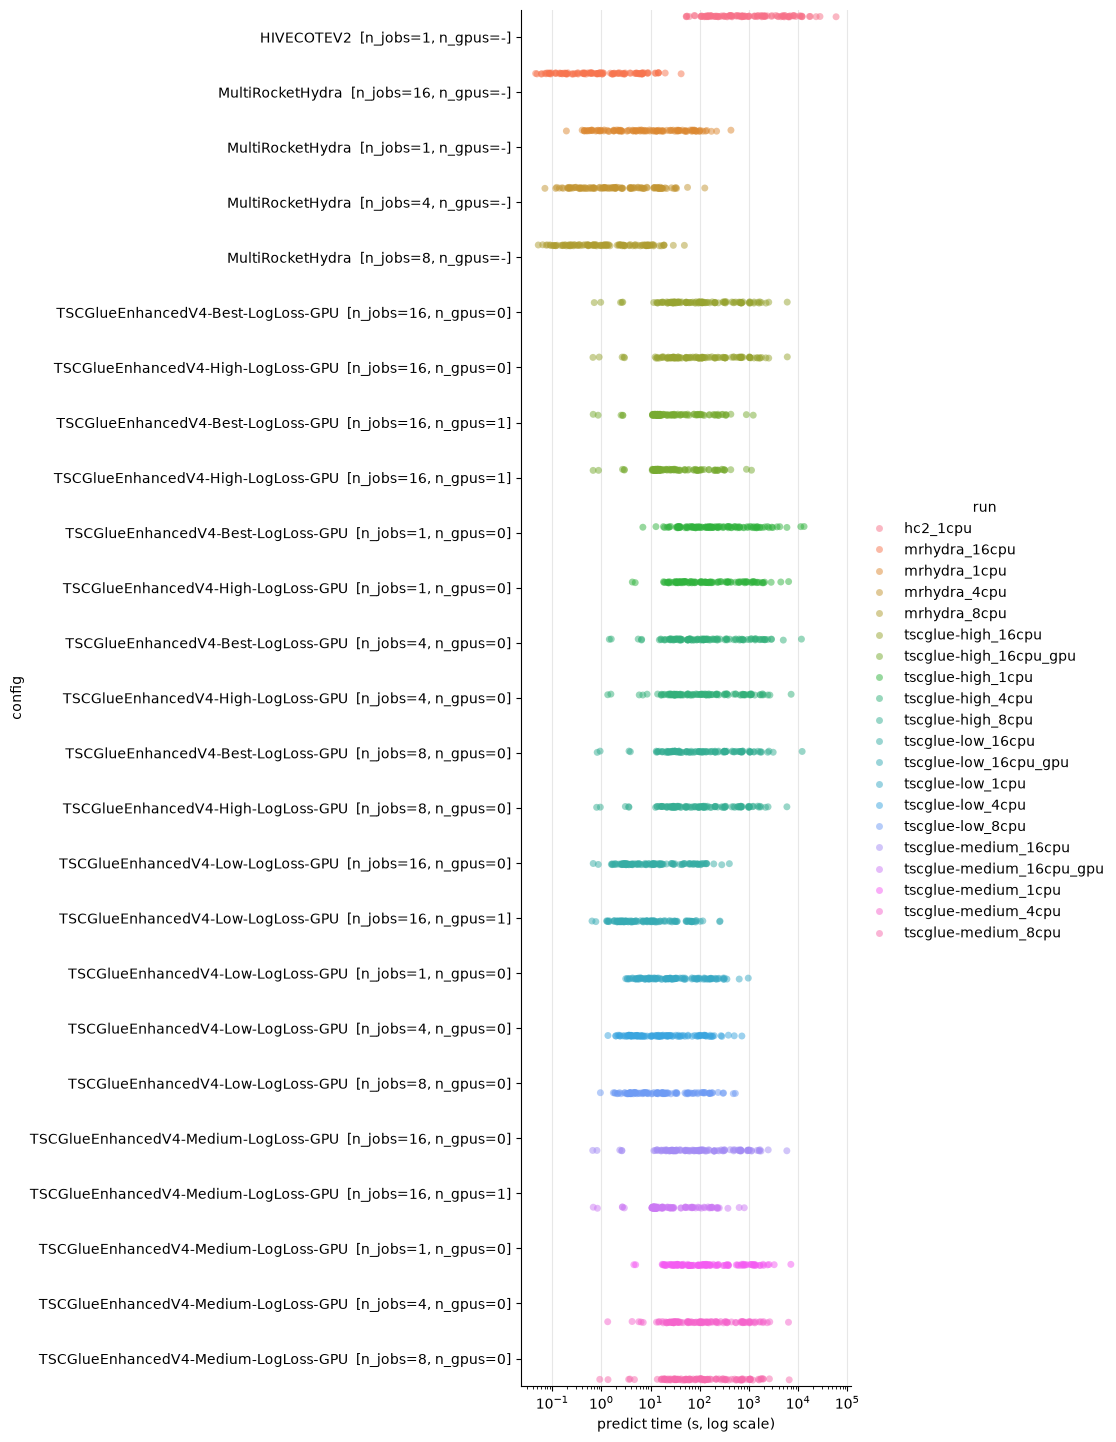

In [ ]:
g = sns.catplot(
    data=df,
    x="predict_s",
    y="config",
    hue="run",
    kind="strip",
    height=2 + 0.5 * df["config"].n_unique(),
    aspect=10 / (2 + 0.5 * df["config"].n_unique()),
    alpha=0.5,
    jitter=0.25,
    dodge=True,
)
g.ax.set_xscale("log")
g.ax.set_xlabel("predict time (s, log scale)")
g.ax.grid(axis="x", alpha=0.3)
plt.show()


In [ ]:
df.group_by(["model", "n_jobs", "n_gpus"]).agg(
    pl.len().alias("n"),
    pl.col("fit_s").mean().alias("fit_s_mean"),
    pl.col("fit_s").median().alias("fit_s_median"),
    pl.col("fit_s").min().alias("fit_s_min"),
    pl.col("fit_s").max().alias("fit_s_max"),
    pl.col("predict_s").mean().alias("predict_s_mean"),
    pl.col("predict_s").median().alias("predict_s_median"),
    pl.col("predict_s").min().alias("predict_s_min"),
    pl.col("predict_s").max().alias("predict_s_max"),
    pl.col("accuracy").mean().alias("accuracy_mean"),
).sort("model")


model,n_jobs,n_gpus,n,fit_s_mean,fit_s_median,fit_s_min,fit_s_max,predict_s_mean,predict_s_median,predict_s_min,predict_s_max,accuracy_mean
str,i64,i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""HIVECOTEV2""",1,null,112,4138.974964,726.7345,26.526,97609.05,3334.325393,743.7225,52.964,59108.238,0.876081
"""MultiRocketHydra""",4,null,112,13.592795,3.1465,0.09,322.32,7.091384,1.8665,0.071,126.41,0.868977
"""MultiRocketHydra""",1,null,112,27.89342,7.798,0.095,398.483,29.90567,7.5935,0.194,430.115,0.868977
"""MultiRocketHydra""",16,null,112,5.448902,1.252,0.081,194.593,2.91683,0.822,0.046,41.771,0.868977
"""MultiRocketHydra""",8,null,112,9.095929,1.695,0.09,245.835,3.871848,1.0685,0.052,48.621,0.868977
…,…,…,…,…,…,…,…,…,…,…,…,…
"""TSCGlueEnhancedV4-Medium-LogLo…",1,0,112,458.475554,129.185,0.902,9666.692,451.642589,114.8065,4.572,7115.286,0.878366
"""TSCGlueEnhancedV4-Medium-LogLo…",16,0,112,211.731634,57.8805,0.557,2615.857,350.634312,88.687,0.666,5896.87,0.878397
"""TSCGlueEnhancedV4-Medium-LogLo…",16,1,112,77.715929,17.757,0.554,1812.337,59.280214,14.59,0.682,804.006,0.878319


In [ ]:
# CPU scaling of fit time, paired per dataset against the 4-CPU run of the same model.
# Pairing matters: the 4/8-CPU runs are incomplete for some models, so raw per-config
# means would compare different dataset subsets.
cpu = df.filter((pl.col("n_gpus") == 0) | pl.col("n_gpus").is_null())
base_4cpu = cpu.filter(pl.col("n_jobs") == 4).select(
    "model", "dataset", "resample", pl.col("fit_s").alias("fit_s_4cpu")
)
scaling = cpu.join(base_4cpu, on=["model", "dataset", "resample"], how="inner").with_columns(
    (pl.col("fit_s_4cpu") / pl.col("fit_s")).alias("speedup_vs_4cpu"),
    pl.col("model")
    .str.replace("TSCGlueEnhancedV4-", "")
    .str.replace("-LogLoss-GPU", "")
    .alias("model_short"),
)

scaling.group_by(["model", "n_jobs"]).agg(
    pl.col("dataset").n_unique().alias("n_datasets"),
    pl.col("fit_s").median().alias("fit_s_median"),
    pl.col("fit_s").sum().alias("fit_s_total"),
    pl.col("fit_s_4cpu").sum().alias("fit_s_total_4cpu"),
    pl.col("speedup_vs_4cpu").median().alias("speedup_median"),
    (pl.col("speedup_vs_4cpu") < 0.95).mean().alias("frac_slower_than_4cpu"),
).sort("model", "n_jobs")

model,n_jobs,n_datasets,fit_s_median,fit_s_total,fit_s_total_4cpu,speedup_median,frac_slower_than_4cpu
str,i64,u32,f64,f64,f64,f64,f64
"""MultiRocketHydra""",1,112,7.798,3124.063,1522.393,0.408867,0.982143
"""MultiRocketHydra""",4,112,3.1465,1522.393,1522.393,1.0,0.0
"""MultiRocketHydra""",8,112,1.695,1018.744,1522.393,1.555814,0.026786
"""MultiRocketHydra""",16,112,1.252,610.277,1522.393,2.027303,0.0
"""TSCGlueEnhancedV4-Best-LogLoss…",1,112,275.123,90648.424,47719.362,0.446126,0.9375
…,…,…,…,…,…,…,…
"""TSCGlueEnhancedV4-Low-LogLoss-…",16,112,10.565,4448.077,10698.752,2.057509,0.0
"""TSCGlueEnhancedV4-Medium-LogLo…",1,112,129.185,51349.262,31706.187,0.632708,0.973214
"""TSCGlueEnhancedV4-Medium-LogLo…",4,112,76.9675,31706.187,31706.187,1.0,0.0


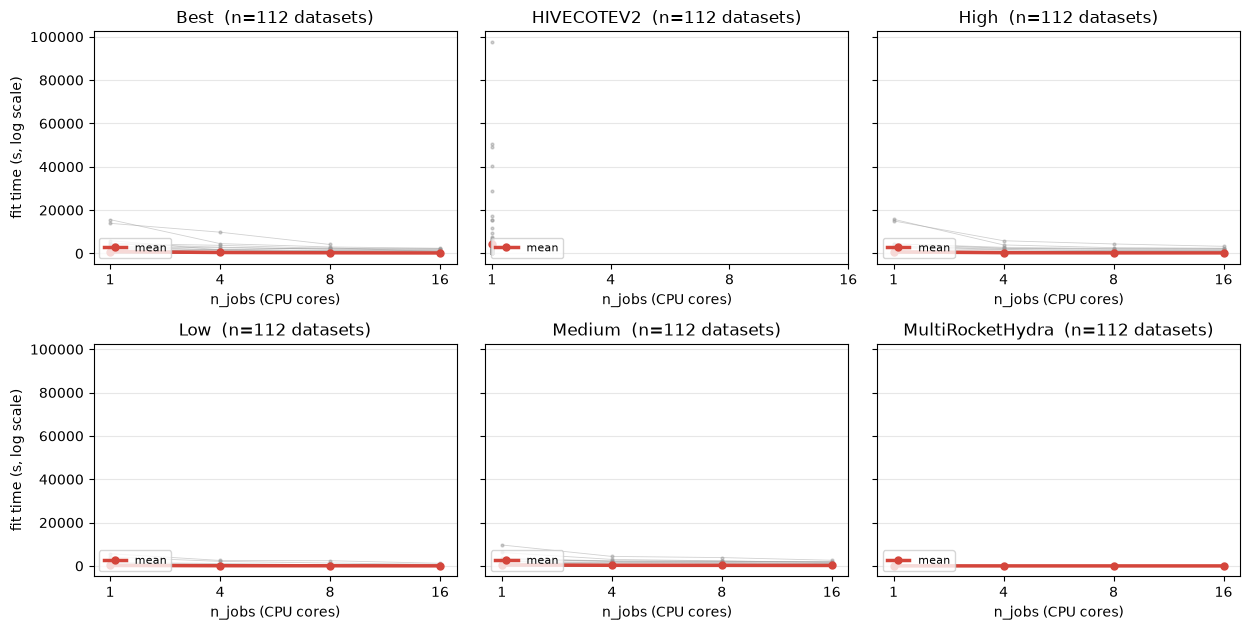

In [ ]:
import numpy as np

cpu_fit = cpu.with_columns(
    pl.col("model")
    .str.replace("TSCGlueEnhancedV4-", "")
    .str.replace("-LogLoss-GPU", "")
    .alias("model_short")
)

models = sorted(cpu_fit["model_short"].unique().to_list())
jobs = sorted(cpu_fit["n_jobs"].unique().to_list())
xpos = {j: i for i, j in enumerate(jobs)}

ncols = 3
nrows = -(-len(models) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, model_short in zip(axes, models):
    sub = cpu_fit.filter(pl.col("model_short") == model_short).sort("n_jobs")
    for (_ds,), g in sub.group_by("dataset", maintain_order=True):
        ax.plot(
            [xpos[j] for j in g["n_jobs"]],
            g["fit_s"],
            color="0.6",
            lw=0.6,
            alpha=0.45,
            marker="o",
            ms=2,
            zorder=1,
        )
    m = sub.group_by("n_jobs").agg(pl.col("fit_s").mean()).sort("n_jobs")
    ax.plot(
        [xpos[j] for j in m["n_jobs"]],
        m["fit_s"],
        color="#d4453b",
        lw=2.5,
        marker="o",
        ms=5,
        zorder=3,
        label="mean",
    )
    ax.set_xticks(range(len(jobs)))
    ax.set_xticklabels([str(j) for j in jobs])
    # ax.set_yscale("log")
    ax.set_title(f"{model_short}  (n={sub['dataset'].n_unique()} datasets)")
    ax.set_xlabel("n_jobs (CPU cores)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="lower left", fontsize=8)

for ax in axes[len(models) :]:
    ax.set_visible(False)
for ax in axes[::ncols]:
    ax.set_ylabel("fit time (s, log scale)")

plt.tight_layout()
plt.show()

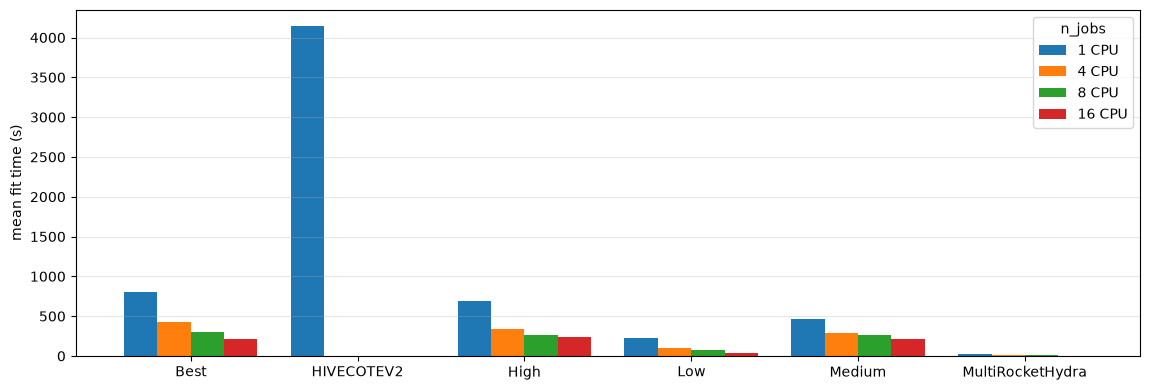

In [ ]:
means = cpu_fit.group_by("model_short", "n_jobs").agg(pl.col("fit_s").mean())
width = 0.8 / len(jobs)

fig, ax = plt.subplots(figsize=(1.6 * len(models) + 2, 4))
for i, j in enumerate(jobs):
    mj = means.filter(pl.col("n_jobs") == j)
    val = dict(zip(mj["model_short"], mj["fit_s"]))
    ax.bar(
        [k + (i - (len(jobs) - 1) / 2) * width for k in range(len(models))],
        [val.get(m, np.nan) for m in models],
        width=width,
        label=f"{j} CPU",
    )
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models)
ax.set_ylabel("mean fit time (s)")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="n_jobs")
plt.tight_layout()
plt.show()

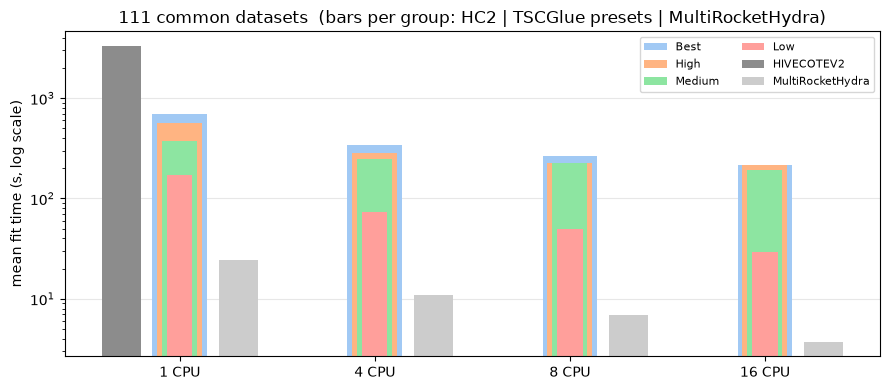

In [ ]:
# HC2 vs TSCGlue presets vs MultiRocketHydra per n_jobs, TSCGlue presets drawn as nested bars.
# CPU-only runs, restricted to datasets every (model, n_jobs) run finished.
common = set.intersection(*[set(g["dataset"]) for _, g in cpu.group_by("model", "n_jobs")])
agg = (
    cpu.filter(pl.col("dataset").is_in(list(common)))
    .group_by("model", "n_jobs")
    .agg(pl.col("fit_s").mean())
)
val = {(m, j): v for m, j, v in agg.iter_rows()}

presets = ["Best", "High", "Medium", "Low"]  # back (widest) to front (narrowest)
colors = dict(zip(presets, sns.color_palette("pastel", 4)))
single = {"HIVECOTEV2": (-0.3, "0.55"), "MultiRocketHydra": (0.3, "0.8")}

fig, ax = plt.subplots(figsize=(9, 4))
for k, j in enumerate(jobs):
    for i, p in enumerate(presets):
        v = val.get((f"TSCGlueEnhancedV4-{p}-LogLoss-GPU", j))
        if v is not None:
            ax.bar(k, v, width=0.28 - 0.05 * i, color=colors[p], label=p if k == 0 else None)
    for m, (dx, c) in single.items():
        v = val.get((m, j))
        if v is not None:
            ax.bar(k + dx, v, width=0.2, color=c, label=m if m not in ax.get_legend_handles_labels()[1] else None)
ax.set_xticks(range(len(jobs)))
ax.set_xticklabels([f"{j} CPU" for j in jobs])
ax.set_ylabel("mean fit time (s, log scale)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.set_title(f"{len(common)} common datasets  (bars per group: HC2 | TSCGlue presets | MultiRocketHydra)")
plt.tight_layout()
plt.show()


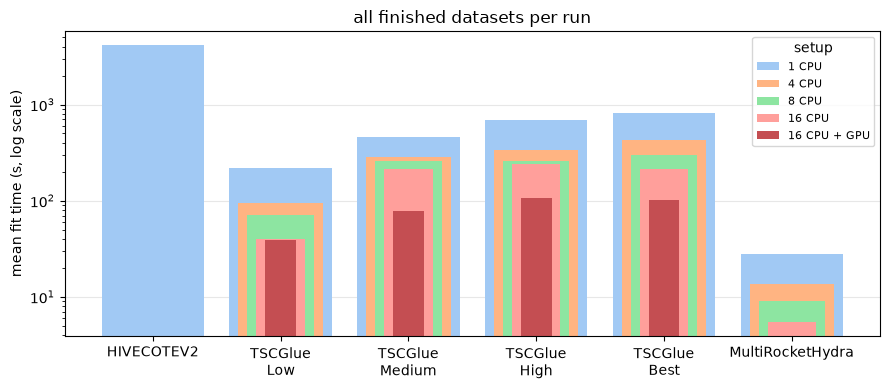

In [ ]:
# Grouped by model/preset, with hardware setups drawn as nested bars (1 CPU widest at the back).
# Mean over all finished datasets per run, so bars may cover different dataset subsets.
setup = (pl.col("n_jobs").cast(pl.String) + " CPU") + pl.when(pl.col("n_gpus") == 1).then(pl.lit(" + GPU")).otherwise(pl.lit(""))
val = {(m, s): v for m, s, v in df.group_by("model", setup.alias("setup")).agg(pl.col("fit_s").mean()).iter_rows()}
setups = [f"{j} CPU" for j in jobs] + ["16 CPU + GPU"]

groups = ["HIVECOTEV2"] + [f"TSCGlueEnhancedV4-{p}-LogLoss-GPU" for p in ["Low", "Medium", "High", "Best"]] + ["MultiRocketHydra"]
labels = ["HIVECOTEV2", "TSCGlue\nLow", "TSCGlue\nMedium", "TSCGlue\nHigh", "TSCGlue\nBest", "MultiRocketHydra"]
setup_colors = dict(zip(setups, sns.color_palette("pastel", len(setups))))
setup_colors["16 CPU + GPU"] = sns.color_palette("deep")[3]  # darker shade of the 16 CPU red

fig, ax = plt.subplots(figsize=(9, 4))
for k, m in enumerate(groups):
    for i, s in enumerate(setups):
        v = val.get((m, s))
        if v is not None:
            ax.bar(k, v, width=0.8 - 0.14 * i, color=setup_colors[s], label=s if k == 1 else None)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(labels)
ax.set_ylabel("mean fit time (s, log scale)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(title="setup", fontsize=8, loc="upper right")
ax.set_title("all finished datasets per run")
plt.tight_layout()
plt.show()


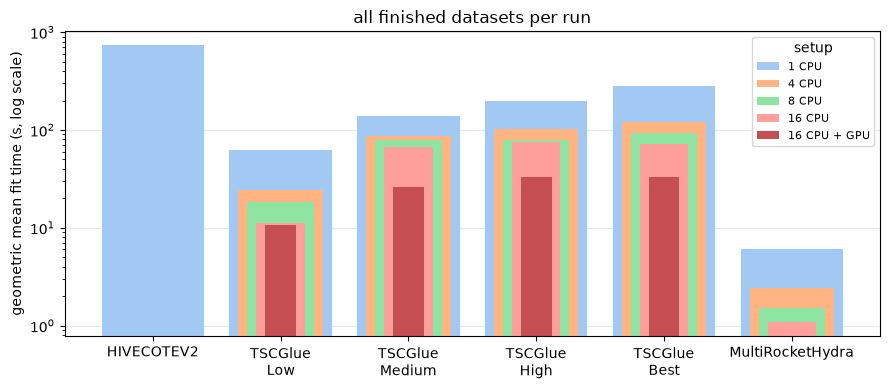

In [ ]:
# Same as above, but geometric mean so a few very slow datasets don't dominate.
val = {(m, s): v for m, s, v in df.group_by("model", setup.alias("setup")).agg(pl.col("fit_s").log().mean().exp()).iter_rows()}

fig, ax = plt.subplots(figsize=(9, 4))
for k, m in enumerate(groups):
    for i, s in enumerate(setups):
        v = val.get((m, s))
        if v is not None:
            ax.bar(k, v, width=0.8 - 0.14 * i, color=setup_colors[s], label=s if k == 1 else None)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(labels)
ax.set_ylabel("geometric mean fit time (s, log scale)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(title="setup", fontsize=8, loc="upper right")
ax.set_title("all finished datasets per run")
plt.tight_layout()
plt.show()

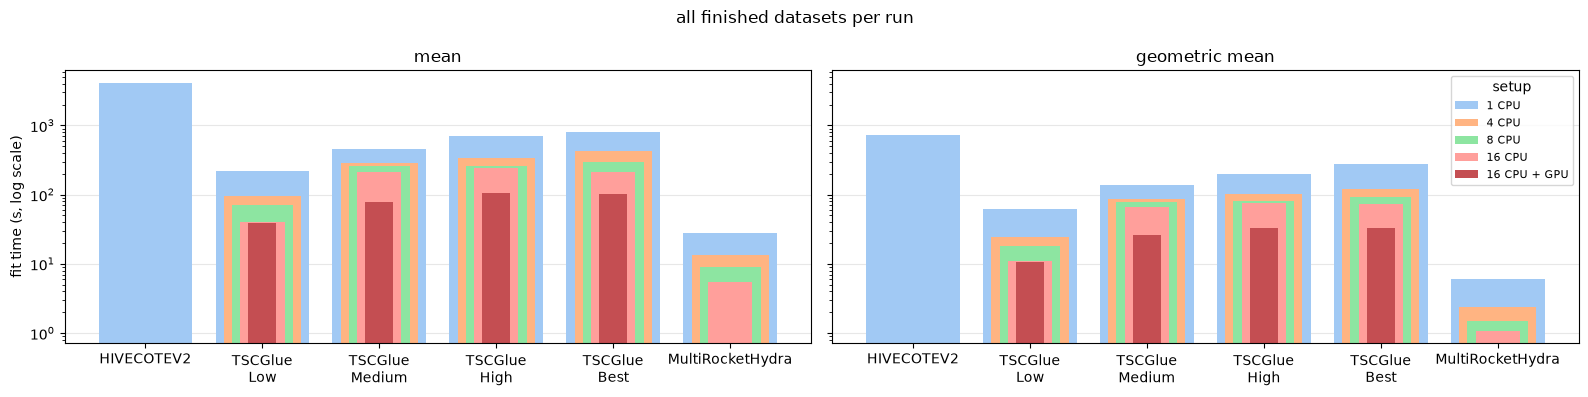

In [ ]:
# Arithmetic mean (left) vs geometric mean (right), shared y-axis.
aggs = {
    "mean": pl.col("fit_s").mean(),
    "geometric mean": pl.col("fit_s").log().mean().exp(),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for ax, (name, expr) in zip(axes, aggs.items()):
    val = {(m, s): v for m, s, v in df.group_by("model", setup.alias("setup")).agg(expr).iter_rows()}
    for k, m in enumerate(groups):
        for i, s in enumerate(setups):
            v = val.get((m, s))
            if v is not None:
                ax.bar(k, v, width=0.8 - 0.14 * i, color=setup_colors[s], label=s if k == 1 else None)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(labels)
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_title(name)
axes[0].set_ylabel("fit time (s, log scale)")
axes[1].legend(title="setup", fontsize=8, loc="upper right")
fig.suptitle("all finished datasets per run")
plt.tight_layout()
plt.show()